se utilizan redes neuronales para identificar si el sexo de una persona es masculino o femenino con base a una imagen, el modelo esta entrenado utilzando el dataset de CelebA.

Para procesar estas imágenes en color y extraer patrones faciales, el modelo implementa una Red Neuronal Convolucional

In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models

# Install or upgrade tensorflow-datasets and protobuf to ensure compatibility
!pip install --upgrade tensorflow-datasets protobuf
!pip install importlib_resources
# IMPORTANT: After running this cell, you might need to restart the Colab runtime (Runtime > Restart runtime)
# for the changes to take effect and resolve potential dependency conflicts.

# 1. Cargar el conjunto de datos CelebA
# Nota: La primera vez que se ejecuta, descargará el dataset (aprox. 1.4 GB)
print("Cargando el dataset CelebA...")
dataset, info = tfds.load('celeb_a', split='train', with_info=True)

# 2. Función de preprocesamiento
def preprocesar_imagen(features):
    # Redimensionar la imagen a 128x128 para estandarizar la entrada
    imagen = tf.image.resize(features['image'], (128, 128))
    # Normalizar los píxeles al rango [0, 1]
    imagen = imagen / 255.0

    # Extraer la etiqueta binaria del sexo.
    # En CelebA, el atributo 'Male' es True (1.0) para masculino y False (0.0) para femenino.
    etiqueta = tf.cast(features['attributes']['Male'], tf.float32)

    return imagen, etiqueta

# 3. Preparar el pipeline de datos para el entrenamiento
# Se toma una muestra pequeña (.take) para una demostración rápida
datos_entrenamiento = (
    dataset.map(preprocesar_imagen)
    .shuffle(1000)
    .batch(32)
    .take(200) # Eliminar este .take() para entrenar con todo el dataset
    .prefetch(tf.data.AUTOTUNE)
)

# 4. Construir la Red Neuronal Convolucional (CNN)
modelo = models.Sequential([
    # Bloque de extracción de características 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),

    # Bloque de extracción de características 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Bloque de extracción de características 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Aplanado y clasificación
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), # Regularización para evitar sobreajuste
    layers.Dense(1, activation='sigmoid') # Una sola neurona para clasificación binaria (0 o 1)
])

# 5. Compilar el modelo
modelo.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

# 6. Entrenar el modelo
print("\nIniciando entrenamiento...")
historial = modelo.fit(datos_entrenamiento, epochs=5)

Cargando el dataset CelebA...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/celeb_a/incomplete.I7AB1L_2.1.0/celeb_a-test.tfrecord-[0-9][0-9][0-9][0-9]…

Dataset celeb_a downloaded and prepared to /root/tensorflow_datasets/celeb_a/2.1.0. Subsequent calls will reuse this data.

Iniciando entrenamiento...
Epoch 1/5


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 213s 1s/step - accuracy: 0.7091 - loss: 0.5364
Epoch 2/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - accuracy: 0.8866 - loss: 0.2728
Epoch 3/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 217s 1s/step - accuracy: 0.9145 - loss: 0.2136
Epoch 4/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 258s 1s/step - accuracy: 0.9356 - loss: 0.1709
Epoch 5/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.9416 - loss: 0.1464


Mostrando algunas imágenes del dataset...


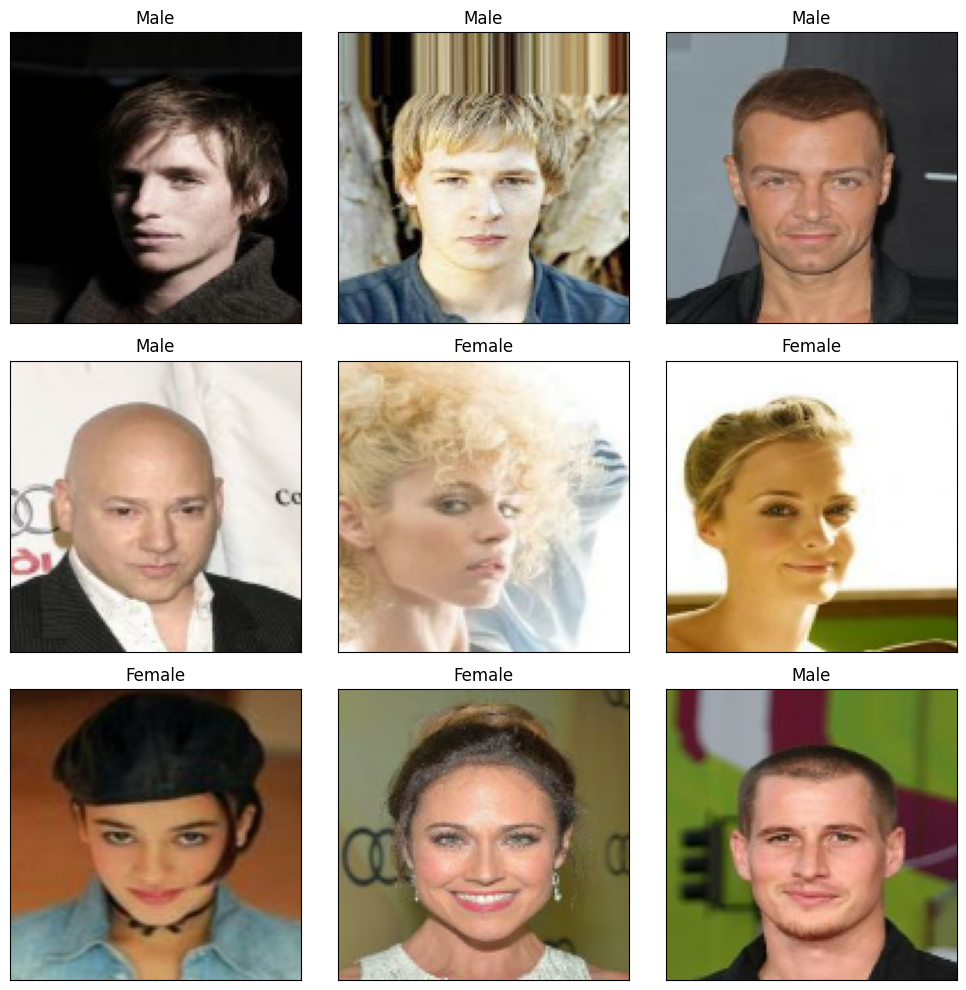

In [3]:
import matplotlib.pyplot as plt

# Visualizar algunas imágenes y sus etiquetas
print("Mostrando algunas imágenes del dataset...")

fig = plt.figure(figsize=(10, 10))
for i, (imagen, etiqueta) in enumerate(datos_entrenamiento.unbatch().take(9)):
    ax = fig.add_subplot(3, 3, i + 1, xticks=[], yticks=[])
    ax.imshow(imagen.numpy())
    ax.set_title(f"{'Male' if etiqueta.numpy() == 1 else 'Female'}")
plt.tight_layout()
plt.show()

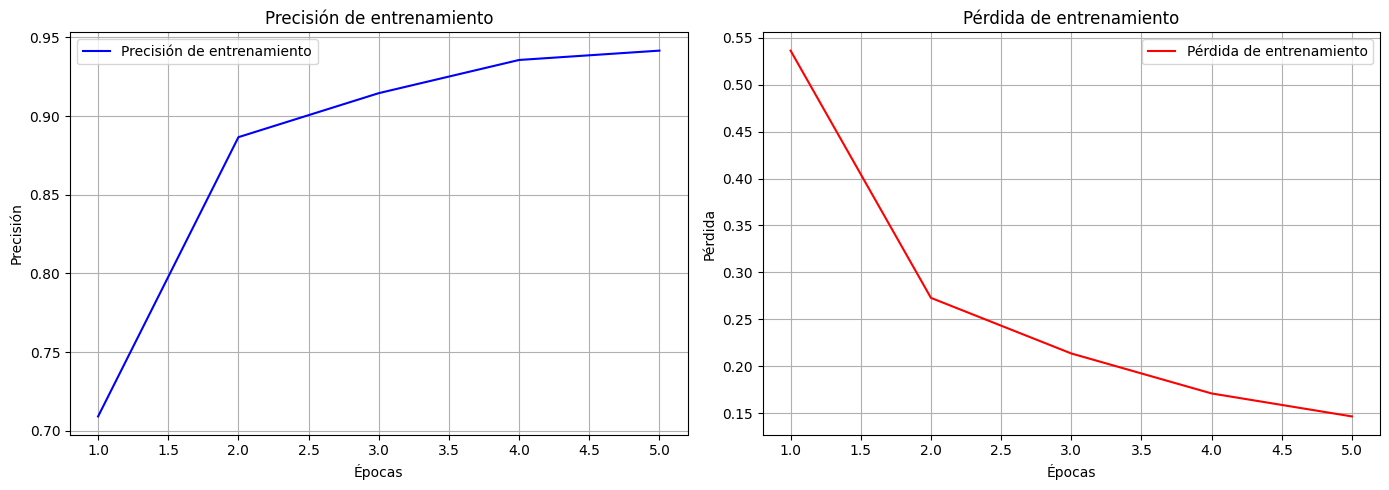

In [4]:
import matplotlib.pyplot as plt

# Obtener los datos de historial
acc = historial.history['accuracy']
loss = historial.history['loss']
epochs = range(1, len(acc) + 1)

# Crear la figura y los subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot de la precisión
ax1.plot(epochs, acc, 'b', label='Precisión de entrenamiento')
ax1.set_title('Precisión de entrenamiento')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Precisión')
ax1.legend()
ax1.grid(True)

# Plot de la pérdida
ax2.plot(epochs, loss, 'r', label='Pérdida de entrenamiento')
ax2.set_title('Pérdida de entrenamiento')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Pérdida')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### Probar el modelo con nuevas imágenes

Para probar el modelo con una nueva imagen, necesitarás:
1.  **Subir una imagen** a tu entorno de Colab o proporcionar una URL a una imagen.
2.  **Reemplazar la ruta de la imagen** en el siguiente código con la ruta de tu imagen.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
Predicción: Male (Confianza: 0.82)


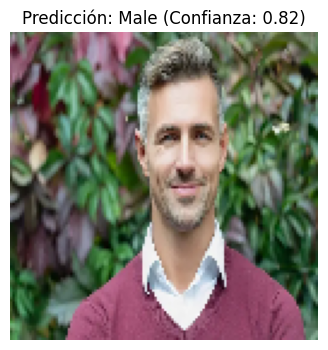

In [9]:
from tensorflow.keras.preprocessing import image
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import requests

img_path = '/content/image.jpg'
img = image.load_img(img_path, target_size=(128, 128))

# Preprocesar la imagen
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

# Realizar la predicción
prediction = modelo.predict(img_array)[0][0]

# Determinar la etiqueta
predicted_gender = 'Male' if prediction > 0.5 else 'Female'
confidence = prediction if prediction > 0.5 else (1 - prediction)

print(f"Predicción: {predicted_gender} (Confianza: {confidence:.2f})")

# Mostrar la imagen
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title(f"Predicción: {predicted_gender} (Confianza: {confidence:.2f})")
plt.axis('off')
plt.show()